1. Import Libraries

In [120]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import(
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import(
    EarlyStopping,
    ModelCheckpoint
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

2. Load DataSet

In [121]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

3. Remove Unnecessary Column

In [122]:
df.drop("customerID", axis=1, inplace = True)

4. Handle TotalCharges

In [123]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].isnull().sum()

np.int64(11)

5. Handle Missing Values

In [124]:
df.dropna(inplace = True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

6. Separate Features and Target

In [125]:
x = df.drop("Churn", axis = 1)
y = df["Churn"]

7. Encode Target

In [126]:
le = LabelEncoder()
y = le.fit_transform(y)


8. Indentify Features Types

In [127]:
categorical_columns = x.select_dtypes(
    include = "object"
).columns

numerical_columns = x.select_dtypes(
    include = np.number
).columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_55090/1075560464.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(


9. One-Hot Encode Features

In [128]:
x = pd.get_dummies(
    x,
    columns = categorical_columns,
    drop_first = True
)

10. Train-Test Split

In [129]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

11. Feature Scaling

In [130]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

12. Build ANN

In [131]:
input_dim = x_train.shape[1]

model = Sequential([
    Dense(
        64,
        activation = "relu",
        input_shape = (input_dim,) 
    ),
    BatchNormalization(),
    Dropout(0.3),
    Dense(
        32,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.2),
    Dense(
        1,
        activation="sigmoid"
    )
])

/Users/vivekkumar/Desktop/project/Customer-Churn-Prediction-Deep-Learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13. Compile the Model

In [132]:
model.compile(
    optimizer = Adam(
        learning_rate = 0.001
    ),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

14. Configure Callbacks

In [133]:
#Early Stopping

early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

#Checkpoint

checkpoint = ModelCheckpoint(
    "../models/best_ann_model.keras",
    monitor = "val_loss",
    save_best_only = True
)

15. Train the Model

In [134]:
history = model.fit(
    x_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping, checkpoint],
    verbose = 1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6927 - loss: 0.6088 - val_accuracy: 0.7884 - val_loss: 0.4658
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7676 - loss: 0.4883 - val_accuracy: 0.7929 - val_loss: 0.4268
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7829 - loss: 0.4608 - val_accuracy: 0.7991 - val_loss: 0.4189
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7936 - loss: 0.4463 - val_accuracy: 0.8044 - val_loss: 0.4117
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7871 - loss: 0.4448 - val_accuracy: 0.8080 - val_loss: 0.4136
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7891 - loss: 0.4355 - val_accuracy: 0.8000 - val_loss: 0.4139
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7944 - loss: 0.4394 - val_accuracy: 0.8062 - val_loss: 0.4100
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7996 - loss: 0.4279 - val_accu

16. Predict Probabilities

In [135]:
y_pred_prob = model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [136]:
y_pred_prob[:10]

array([[0.01179711],
       [0.63326055],
       [0.01656811],
       [0.20863998],
       [0.1282141 ],
       [0.39681593],
       [0.03039559],
       [0.19011842],
       [0.72609925],
       [0.0123996 ]], dtype=float32)

17. Convert Probability to Class

In [137]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [138]:
y_pred = y_pred.flatten()

In [139]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

18. Accuracy

In [151]:
accuracy = accuracy_score(
    y_test,
    y_pred
)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7974


19. Precision

In [141]:
precision = precision_score(
    y_test,
    y_pred
)
print(f"Precision: {precision:.4f}")

Precision: 0.6422


20. Recall

In [142]:
recall = recall_score(
    y_test,
    y_pred
)
print(f"Recall: {recall:.4f}")

Recall: 0.5374


21. F1Score

In [143]:
f1 = f1_score(
    y_test,
    y_pred
)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.5852


22. Roc-AUC

In [144]:
roc_auc = roc_auc_score(
    y_test,
    y_pred
)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7145


23. Classification Report

In [145]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



24. Confusion Matrix

In [146]:
cm = confusion_matrix(
    y_test,
    y_pred
)

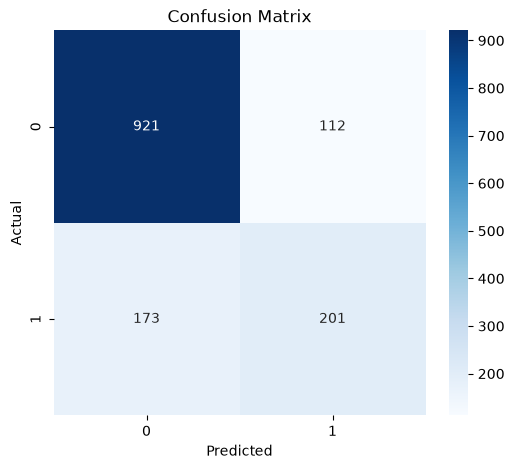

In [147]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

25. ROC Curve

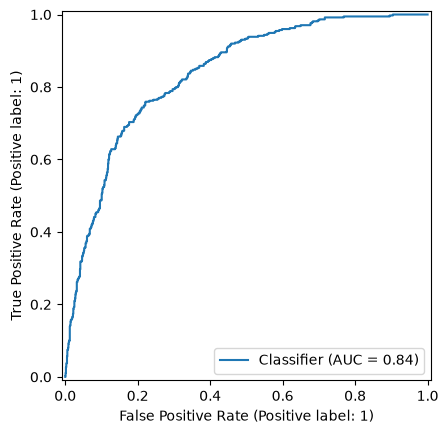

In [148]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob
)
plt.show()

26. Precision-Recall Curve

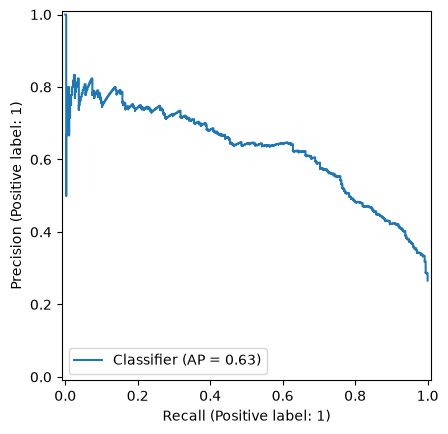

In [149]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_prob
)
plt.show()

27. Results Table

In [152]:
results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    })
results

,Metric,Value
0,Accuracy,0.797441
1,Precision,0.642173
2,Recall,0.537433
3,F1 Score,0.585153
4,ROC-AUC,0.714506


### Key Pointers

#### Objective
Evaluated the Artificial Neural Network using multiple performance metrics to measure its effectiveness in predicting customer churn.

#### Tasks Performed
- Generated prediction probabilities and converted them into binary predictions.
- Evaluated the model using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Generated the Classification Report and Confusion Matrix.
- Visualized ROC Curve and Precision-Recall Curve.
- Analyzed the model's overall performance and generalization.

#### Key Learnings
- ANN outputs probabilities that are converted into class labels using a threshold.
- Accuracy alone is not sufficient for evaluating churn prediction models.
- F1 Score and ROC-AUC provide a better understanding of model performance.
- Confusion Matrix helps identify False Positives and False Negatives.

#### Outcome
Successfully evaluated the baseline ANN model. The results provide a strong baseline for further optimization using architecture improvements and hyperparameter tuning.